# Fontana Emanuele, Ex 9 #

In [1]:
#import of the libraries
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog
from skimage import color


Extracting tar file
Done!


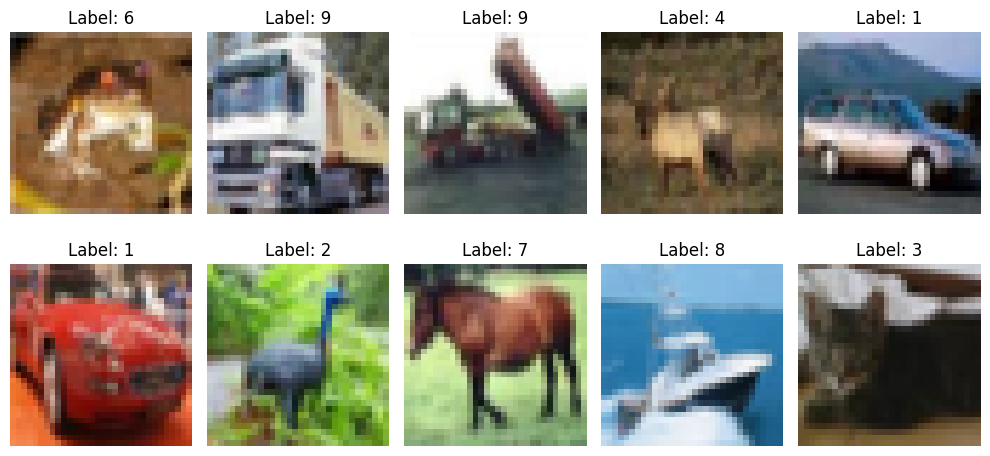

In [2]:
from torchvision import datasets

#load the dataset
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)

# Divide into images and labels
X = [np.array(img) for img, label in dataset]     # Immagini come array NumPy
y = [label for img, label in dataset]             # Etichette

# converting to numpy arrays
X = np.array(X)   
y = np.array(y) 



#plot the first 10 images of the dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


In [3]:
diffrent_space=True

if diffrent_space:
    #change representation using both color histogram and HOG. Each image is represented by a vector which is the concatenation of the two representations
    hog_features = []
    color_hist_features = []
    for img in X:
        # Convert to grayscale for HOG
        img_gray = color.rgb2gray(img)
        hog_feature = hog(img_gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=False)
        hog_features.append(hog_feature)

        # Color histogram
        hist = np.histogram(img, bins=256, range=(0, 256))[0]
        color_hist_features.append(hist)

    # Concatenate HOG and color histogram features
    X = np.concatenate((np.array(hog_features), np.array(color_hist_features)), axis=1)
    
    #normalization to have 0 mean and 1 variance
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

print("Number of dimensions: ", X.shape[1])

#PCA to reduce the number of dimensions
pca = PCA(n_components=0.9)  # Keep 90% of variance
X_pca = pca.fit_transform(X.reshape(X.shape[0], -1))
print("Number of dimensions after PCA: ", X_pca.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


Number of dimensions:  288
Number of dimensions after PCA:  100


5-fold Cross-Validation Results:


c:\Users\fonta\Desktop\Uni\Repo\ComputerVision\env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\fonta\Desktop\Uni\Repo\ComputerVision\env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.752.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundati

KNN (k=3): Mean accuracy = 0.2334, Std = 0.0032
KNN (k=5): Mean accuracy = 0.2452, Std = 0.0022
KNN (k=7): Mean accuracy = 0.2493, Std = 0.0040
LogReg: Mean accuracy = 0.2762, Std = 0.0026

Best model based on cross-validation: LogReg with accuracy 0.2762
Test set accuracy: 0.2901


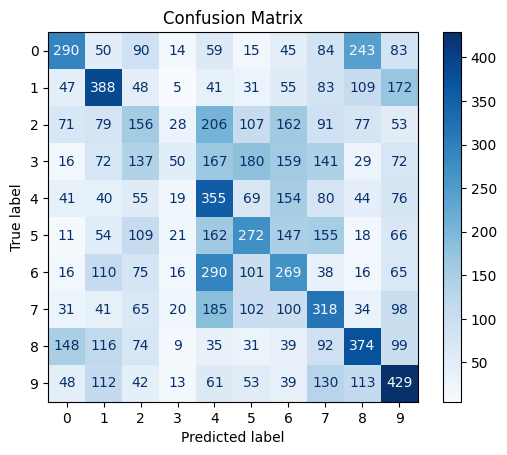

In [4]:
# Initialize models with different k values
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn7 = KNeighborsClassifier(n_neighbors=7)
log_reg = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-3)

# List of models to evaluate
models = [
    ('KNN (k=3)', knn3),
    ('KNN (k=5)', knn5),
    ('KNN (k=7)', knn7),
    ('LogReg', log_reg)
]

# Perform 5-fold cross-validation for each model
best_score = 0
best_model_name = ''
best_model = None

print("5-fold Cross-Validation Results:")
for name, model in models:
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = np.mean(cv_scores)
    print(f"{name}: Mean accuracy = {mean_score:.4f}, Std = {np.std(cv_scores):.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model_name = name
        best_model = model

print(f"\nBest model based on cross-validation: {best_model_name} with accuracy {best_score:.4f}")

# Train the best model on the entire training set and evaluate on test set
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Test set accuracy: {accuracy:.4f}')

# Set clf to best_model for confusion matrix plotting
clf = best_model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

